In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
path_gla_station_info = "data/validation/glacier-station/glacier_station_info.gpkg" 
path_hma_extent = "data/hma-extent/HMA/hma_gtng_202307_subregions.gpkg"

In [3]:
hma = gpd.read_file(path_hma_extent)
gla_info_gdf = gpd.read_file(path_gla_station_info)
gla_show_gdf = gla_info_gdf.drop_duplicates(subset=['geometry']) # 每个实测脚点只显示一个（实测日期不同但位置相同）
gla_show_gdf

,type,character,latitude,longitude,image_date,image_id,geometry
0,Glacier,Clean Ice,43.081868,94.348077,2020-08-02,20200802T043709_20200802T043815_T46TFN,POINT (94.34808 43.08187)
1,Glacier,Clean Ice,43.037217,94.450388,2020-08-02,20200802T043709_20200802T043815_T46TFN,POINT (94.45039 43.03722)
2,Glacier,Clean Ice,43.002578,94.537592,2020-08-02,20200802T043709_20200802T043815_T46TFN,POINT (94.53759 43.00258)
3,Glacier,Clean Ice,43.059797,94.304132,2020-08-02,20200802T043709_20200802T043815_T46TFN,POINT (94.30413 43.0598)
4,Glacier,Clean Ice,43.122477,94.267053,2020-08-02,20200802T043709_20200802T043815_T46TFN,POINT (94.26705 43.12248)
...,...,...,...,...,...,...,...
1587,Non-Glacier,Bare Rock,33.604766,94.845800,2020-07-25,20200725T042711_20200725T042709_T46SFC,POINT (94.8458 33.60477)
1588,Non-Glacier,Bare Rock,33.617776,94.790181,2020-07-25,20200725T042711_20200725T042709_T46SFC,POINT (94.79018 33.61778)
1589,Non-Glacier,Bare Rock,33.590611,94.737996,2020-07-25,20200725T042711_20200725T042709_T46SFC,POINT (94.738 33.59061)
1590,Non-Glacier,Bare Rock,33.560290,94.788637,2020-07-25,20200725T042711_20200725T042709_T46SFC,POINT (94.78864 33.56029)


In [4]:
lon_center = (gla_info_gdf.bounds.minx + gla_info_gdf.bounds.maxx) / 2
lat_center = (gla_info_gdf.bounds.miny + gla_info_gdf.bounds.maxy) / 2

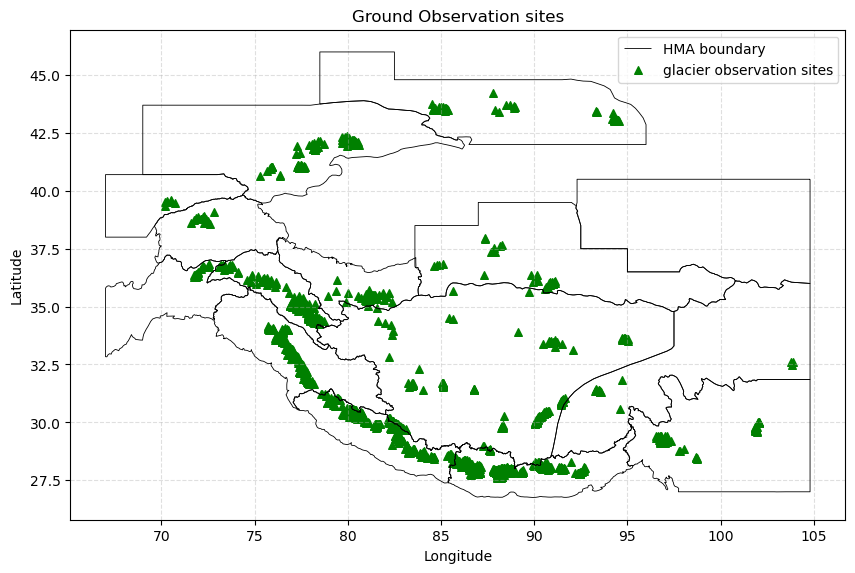

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
hma.boundary.plot(ax=ax, edgecolor="black", linewidth=0.6, label="HMA boundary")
ax.scatter(
    lon_center, lat_center,
    marker="^", s=30, color="green",
    label="glacier observation sites")
ax.legend()
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_title("Ground Observation sites")
fig.savefig("figures/validation/glacier_sample.png", bbox_inches='tight', dpi=200)